In [ ]:
# 1._ Cargamos Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", 100)
sns.set(style="whitegrid")


In [ ]:
# 2._ Cargamos el dataset, y nos debe de mostrar las 5 primeras filas del mismo

In [ ]:
DATA_PATH = Path("../..") / "data" / "raw" / "dataset_practica_final.csv"

df = pd.read_csv(DATA_PATH)
df.head()

0
1
0
0
0
0
0
0
0
0


In [ ]:
# 3._ vista general del dataset

In [3]:
df.shape  # filas, columnas


(119390, 32)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [5]:
df.describe()


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
# 4._ Analisis de la variable objetivo

In [6]:
df["is_canceled"].value_counts()


is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [7]:
df["is_canceled"].value_counts(normalize=True) * 100


is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

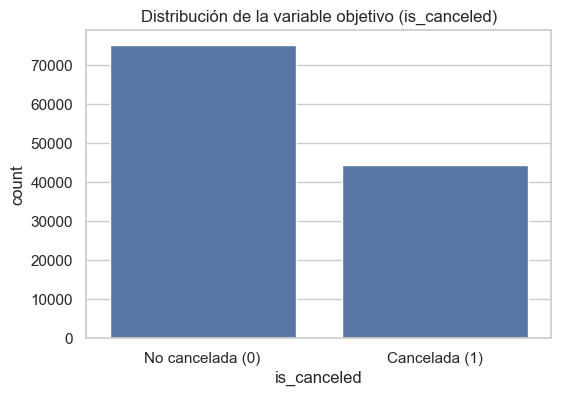

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="is_canceled")
plt.title("Distribución de la variable objetivo (is_canceled)")
plt.xticks([0, 1], ["No cancelada (0)", "Cancelada (1)"])
plt.savefig("../../outputs/distribucion_objetivo.png", dpi=300, bbox_inches="tight")

plt.show()



In [ ]:
# Informacion grafica proporcionada por el dataset

In [ ]:
# 5._ Deteccion de valores nulos

In [9]:
df.isnull().sum().sort_values(ascending=False)


company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

In [ ]:
# Las columnas que tienen nulos son: "agent", "company", "country", "children", "customer_type", "reservation_status_date". Estas columnas pueden ser importantes para el análisis, por lo que es necesario decidir cómo manejar estos valores nulos (por ejemplo, imputación, eliminación, etc.) dependiendo del contexto y la cantidad de datos faltantes.

In [ ]:
# 6._ Separar variables numericas y categorias

In [10]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

numeric_cols, categorical_cols


C:\Users\alexd\AppData\Local\Temp\ipykernel_10244\736679487.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


(['is_canceled',
  'lead_time',
  'arrival_date_year',
  'arrival_date_week_number',
  'arrival_date_day_of_month',
  'stays_in_weekend_nights',
  'stays_in_week_nights',
  'adults',
  'children',
  'babies',
  'is_repeated_guest',
  'previous_cancellations',
  'previous_bookings_not_canceled',
  'booking_changes',
  'agent',
  'company',
  'days_in_waiting_list',
  'adr',
  'required_car_parking_spaces',
  'total_of_special_requests'],
 ['hotel',
  'arrival_date_month',
  'meal',
  'country',
  'market_segment',
  'distribution_channel',
  'reserved_room_type',
  'assigned_room_type',
  'deposit_type',
  'customer_type',
  'reservation_status',
  'reservation_status_date'])

In [ ]:
# 7._ Distribucion de algunas variables numericas y categoricas

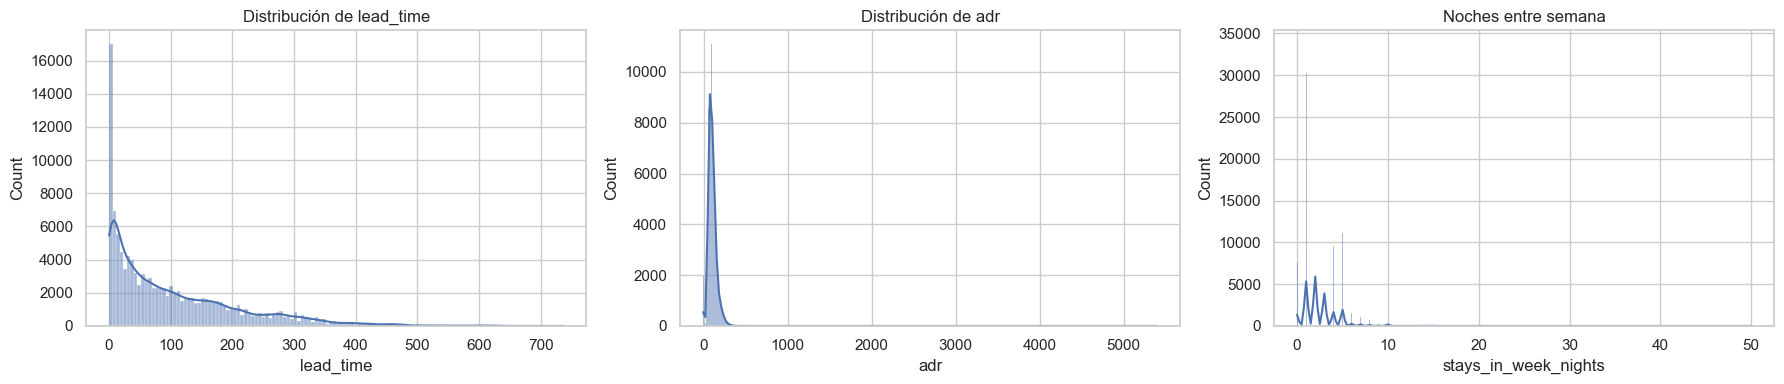

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(df["lead_time"], kde=True, ax=axes[0])
axes[0].set_title("Distribución de lead_time")

sns.histplot(df["adr"], kde=True, ax=axes[1])
axes[1].set_title("Distribución de adr")

sns.histplot(df["stays_in_week_nights"], kde=True, ax=axes[2])
axes[2].set_title("Noches entre semana")

plt.tight_layout()
plt.savefig("../../outputs/distribuciones_numericas.png", dpi=300, bbox_inches="tight")

plt.show()



In [ ]:
# 8._ Relacion de algunas variables con el target
# ejemplo: hotel, market_segment, customer_type vs is_canceled

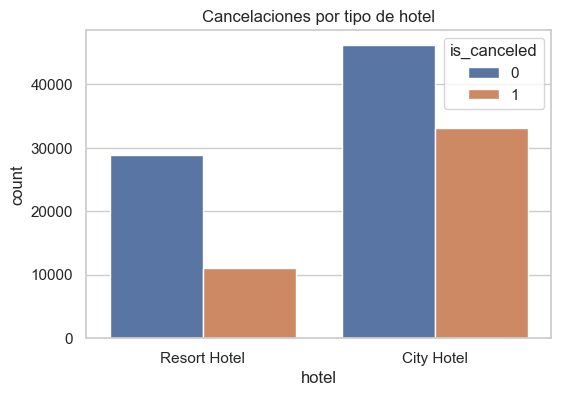

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="hotel", hue="is_canceled")
plt.title("Cancelaciones por tipo de hotel")
plt.savefig("../../outputs/cancelaciones_por_tipo_hotel.png", dpi=300, bbox_inches="tight")

plt.show()



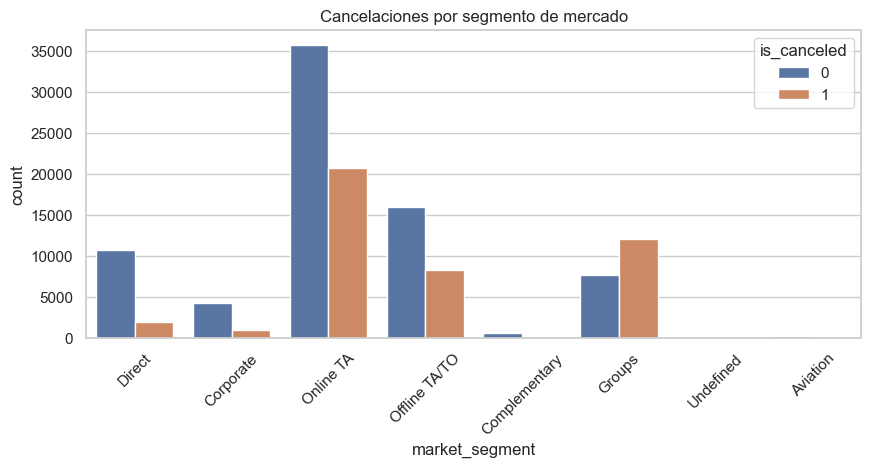

In [13]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x="market_segment", hue="is_canceled")
plt.title("Cancelaciones por segmento de mercado")
plt.xticks(rotation=45)
plt.savefig("../../outputs/cancelaciones_por_segmento.png", dpi=300, bbox_inches="tight")

plt.show()



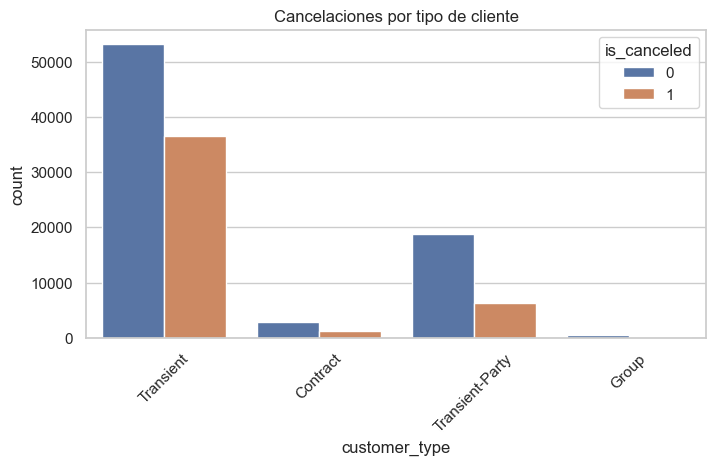

In [14]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="customer_type", hue="is_canceled")
plt.title("Cancelaciones por tipo de cliente")
plt.xticks(rotation=45)
plt.savefig("../../outputs/cancelaciones_por_tipo_cliente.png", dpi=300, bbox_inches="tight")

plt.show()



In [ ]:
# 9._ Correlacion entre variables numericas

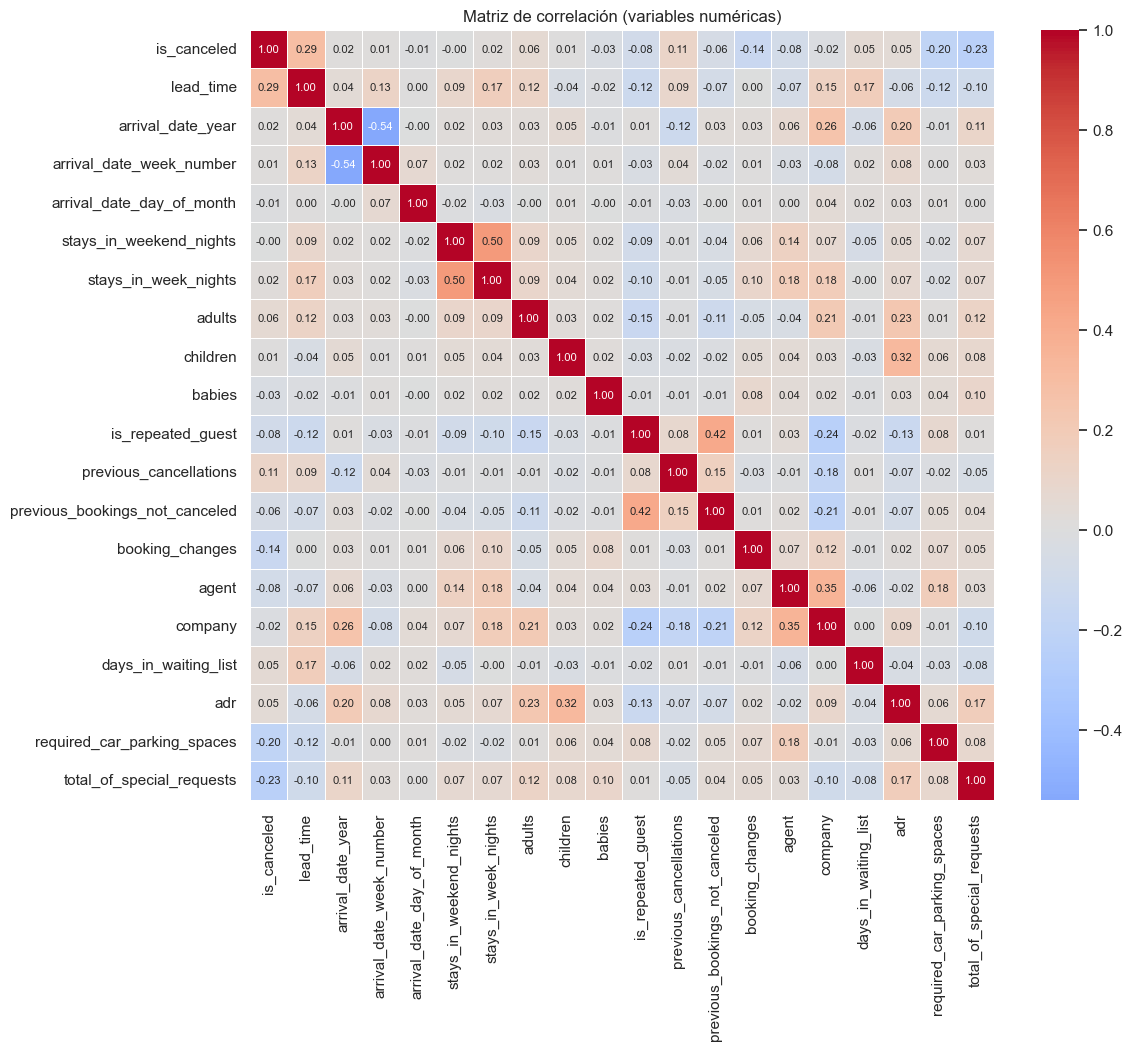

In [15]:
plt.figure(figsize=(12, 10))
corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,          # Muestra los valores numéricos
    fmt=".2f",           # Formato de los números (2 decimales)
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title("Matriz de correlación (variables numéricas)")
plt.savefig("../../outputs/matriz_correlacion.png", dpi=300, bbox_inches="tight")

plt.show()




In [ ]:
# Para facilitar la interpretación, se pueden destacar las correlaciones más fuertes (por ejemplo, > 0.5 o < -0.5) con un color diferente o anotarlas de alguna manera. Esto ayuda a identificar rápidamente qué variables numéricas están más relacionadas entre sí y con la variable objetivo "is_canceled".

In [ ]:
# Conclusiones del EDA inicial:
# El análisis exploratorio muestra que la mayoría de las reservas no se cancelan, lo que genera un desbalance en la variable objetivo. Este desbalance puede afectar la capacidad del modelo para identificar correctamente las cancelaciones, por lo que métricas como F1-score, recall y ROC-AUC son más adecuadas que la simple accuracy.